# FIRST **RUN**

In [44]:
!rm -rf /content/workspace_50k_test
!mkdir -p /content/workspace_50k_test/output
%cd /content/workspace_50k_test


shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
/content/workspace_50k_test


In [45]:
%%writefile env.py
import numpy as np

class MECEnv:
    def __init__(self, num_agents=4):
        self.n = num_agents
        self.obs_len = 5
        self.act_len = 1
        self.latency_thresholds = [0.5]*self.n
        self.quality_constraints = [0.9]*self.n
        self.num_channels = 2

    def reset(self):
        self.state = np.random.rand(self.n, self.obs_len)
        return self.state

    def step(self, actions):
        reward = -np.sum(np.square(actions))
        next_state = np.random.rand(self.n, self.obs_len)
        info = {
            "energy":  np.sum(np.abs(actions))*0.1,
            "latency": np.random.rand()*0.3 + 0.4,
            "phi":     0.95 - np.mean(np.abs(actions))*0.1
        }
        self.state = next_state
        done = False
        return next_state, reward, done, info


Writing env.py


In [46]:
%%writefile ppo_model.py
import torch, torch.nn as nn

class Actor(nn.Module):
    def __init__(self, s_dim, a_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(s_dim,64), nn.ReLU(),
            nn.Linear(64,64),    nn.ReLU(),
            nn.Linear(64,a_dim)
        )
        self.log_std = nn.Parameter(torch.zeros(a_dim))

    def forward(self, x):
        mean = self.fc(x)
        std  = self.log_std.exp()
        return mean, std

class Critic(nn.Module):
    def __init__(self, s_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(s_dim,64), nn.ReLU(),
            nn.Linear(64,64),    nn.ReLU(),
            nn.Linear(64,1)
        )
    def forward(self,x): return self.fc(x)


Writing ppo_model.py


In [47]:
%%writefile ppo_agent.py
import numpy as np, torch, torch.nn as nn, torch.optim as optim
from ppo_model import Actor, Critic

class PPOAgent:
    def __init__(self, s_dim, a_dim, gamma=0.99, clip=0.1, lr=1e-4, ent=1e-3):
        self.A, self.C = Actor(s_dim,a_dim), Critic(s_dim)
        self.oA = optim.Adam(self.A.parameters(), lr=lr)
        self.oC = optim.Adam(self.C.parameters(), lr=lr)
        self.g, self.c, self.ent = gamma, clip, ent

    def select_action(self, s_flat):
        s = torch.tensor(s_flat, dtype=torch.float32)
        mu, sd = self.A(s)
        dist = torch.distributions.Normal(mu, sd)
        a  = dist.sample()
        lp = dist.log_prob(a)
        return a.detach().numpy(), lp.detach().numpy()

    # alias for backward-compatibility
    select = select_action

    def _eval(self,S,A):
        mu,sd = self.A(S)
        dist  = torch.distributions.Normal(mu,sd)
        return dist.log_prob(A), dist.entropy(), self.C(S).squeeze()

    def update(self,S,A,old_lp,R):
        S = torch.tensor(np.array(S),dtype=torch.float32)
        A = torch.tensor(np.array(A),dtype=torch.float32)
        old_lp = torch.tensor(np.array(old_lp),dtype=torch.float32)
        R = torch.tensor(np.array(R),dtype=torch.float32)

        for _ in range(5):
            lp, ent, V = self._eval(S,A)
            adv  = R - V.detach()
            rat  = torch.exp(lp.sum(-1)-old_lp.sum(-1))
            L_surr = torch.min(rat*adv,
                               torch.clamp(rat,1-self.c,1+self.c)*adv).mean()
            lossA = -L_surr - self.ent*ent.mean()
            lossC = nn.MSELoss()(V,R)

            self.oA.zero_grad(); lossA.backward(retain_graph=True); self.oA.step()
            self.oC.zero_grad(); lossC.backward();                 self.oC.step()


Writing ppo_agent.py


In [48]:
%%writefile run_ppo.py
import numpy as np, pandas as pd
from env import MECEnv
from ppo_agent import PPOAgent

EP, N, UPDATE = 50_000, 4, 256
env = MECEnv(N)
sd, ad = env.obs_len*N, env.act_len*N
agent = PPOAgent(sd, ad)

R,E,L,P = [],[],[],[]
Sb,Ab,Lpb,Rb = [],[],[],[]

for ep in range(1, EP+1):
    s = env.reset(); flat = s.reshape(-1)
    a, lp = agent.select_action(flat)
    ns,r,_,info = env.step(a.reshape(N,-1))

    Sb.append(flat); Ab.append(a.reshape(-1)); Lpb.append(lp.reshape(-1)); Rb.append(r)
    R.append(r); E.append(info['energy']); L.append(info['latency']); P.append(info['phi'])

    if ep%UPDATE==0:
        G,ret=0,[];
        for rew in reversed(Rb):
            G=rew+agent.g*G; ret.insert(0,G)
        agent.update(Sb,Ab,Lpb,ret)
        Sb,Ab,Lpb,Rb=[],[],[],[]

    if ep%1000==0: print(f"[PPO] {ep}/{EP} r={r:.2f}")

pd.DataFrame({'Episode':np.arange(1,EP+1),
              'Reward':R,'Energy':E,'Latency':L,'Phi':P}
            ).to_csv("output/ppo_rewards.csv",index=False)


Writing run_ppo.py


In [49]:
%%writefile Model.py
import torch, torch.nn as nn
class Actor(nn.Module):
    def __init__(self,i,o): super().__init__(); self.f=nn.Sequential(
        nn.Linear(i,64), nn.ReLU(), nn.Linear(64,64), nn.ReLU(), nn.Linear(64,o), nn.Tanh())
    def forward(self,x): return self.f(x)

class Critic(nn.Module):
    def __init__(self,i): super().__init__(); self.f=nn.Sequential(
        nn.Linear(i,64), nn.ReLU(), nn.Linear(64,64), nn.ReLU(), nn.Linear(64,1))
    def forward(self,x): return self.f(x)


Writing Model.py


In [50]:
%%writefile Memory.py
import random
class ReplayBuffer:
    def __init__(self, max_size=200_000): self.buf, self.max = [], max_size
    def add(self, item): self.buf.append(item); self.buf=self.buf[-self.max:]
    def sample(self, n): import random; return random.sample(self.buf, n)
    def __len__(self): return len(self.buf)


Writing Memory.py


In [51]:
%%writefile MADDPG.py
import numpy as np, torch, torch.optim as optim, torch.nn as nn
from Model import Actor, Critic
from Memory import ReplayBuffer

class MADDPG:
    def __init__(self, N, obs_d, act_d, gamma=0.99, tau=0.005, batch=256):
        self.N, self.obs_d, self.act_d = N, obs_d, act_d
        self.g, self.tau, self.b = gamma, tau, batch
        self.A = [Actor(obs_d, act_d) for _ in range(N)]
        self.C = [Critic((obs_d+act_d)*N) for _ in range(N)]
        self.tA= [Actor(obs_d, act_d) for _ in range(N)]
        self.tC= [Critic((obs_d+act_d)*N) for _ in range(N)]
        self.oA= [optim.Adam(a.parameters(),1e-4) for a in self.A]
        self.oC= [optim.Adam(c.parameters(),1e-4) for c in self.C]
        self.buf = ReplayBuffer()

    # ---------- interaction ----------
    def select_action(self, S):
        return np.stack([self.A[i](torch.FloatTensor(S[i])).detach().numpy()
                         for i in range(self.N)])

    # alias for runner compatibility
    select = select_action

    def store(self,tr): self.buf.add(tr)

    # ---------- learning ----------
    def train(self):
        if len(self.buf)<self.b: return
        import random
        B = random.sample(self.buf.buf, self.b)
        S,A,R,S2 = map(np.array, zip(*B))
        S_flat  = torch.FloatTensor(S.reshape(self.b,-1))
        A_flat  = torch.FloatTensor(A.reshape(self.b,-1))
        S2_flat = torch.FloatTensor(S2.reshape(self.b,-1))
        R = torch.FloatTensor(R)

        for i in range(self.N):
            with torch.no_grad():
                na = torch.cat([self.tA[j](
                    torch.FloatTensor(S2[:,j,:])) for j in range(self.N)],1)
                y  = R[:,i] + self.g * self.tC[i](torch.cat([S2_flat,na],1)).squeeze()
            q   = self.C[i](torch.cat([S_flat,A_flat],1)).squeeze()
            lc  = nn.MSELoss()(q,y); self.oC[i].zero_grad(); lc.backward(); self.oC[i].step()

            curr_a = torch.cat([self.A[j](torch.FloatTensor(S[:,j,:])) for j in range(self.N)],1)
            la = -self.C[i](torch.cat([S_flat,curr_a],1)).mean()
            self.oA[i].zero_grad(); la.backward(); self.oA[i].step()

            for tp,p in zip(self.tC[i].parameters(), self.C[i].parameters()):
                tp.data.copy_(tp.data*(1-self.tau)+p.data*self.tau)
            for tp,p in zip(self.tA[i].parameters(), self.A[i].parameters()):
                tp.data.copy_(tp.data*(1-self.tau)+p.data*self.tau)


Writing MADDPG.py


In [52]:
%%writefile run_ddpg.py
import numpy as np, pandas as pd
from env import MECEnv; from MADDPG import MADDPG
EP, N = 50_000, 4
env = MECEnv(N); agent = MADDPG(N, env.obs_len, env.act_len)
R,E,L,P = [],[],[],[]
for ep in range(1,EP+1):
    s = env.reset()
    a = agent.select_action(s)
    ns,r,_,info = env.step(a)
    agent.store((s,a,[r]*N,ns)); agent.train()
    R.append(r);E.append(info['energy']);L.append(info['latency']);P.append(info['phi'])
    if ep%1000==0: print(f"[MADDPG] {ep}/{EP} r={r:.2f}")
pd.DataFrame({'Episode':np.arange(1,EP+1),
              'Reward':R,'Energy':E,'Latency':L,'Phi':P}
            ).to_csv("output/ddpg_rewards.csv",index=False)


Writing run_ddpg.py


In [53]:
%%writefile plot_all_results.py
import pandas as pd, matplotlib.pyplot as plt, os
def smooth(y,w=500): return y.rolling(w,1).mean()
plt.figure(figsize=(10,5))
for lb,csv in {"PPO":"output/ppo_rewards.csv","MADDPG":"output/ddpg_rewards.csv"}.items():
    if not os.path.exists(csv):
        print(f"[plot] {csv} missing, skip"); continue
    d=pd.read_csv(csv); plt.plot(d['Episode'],smooth(d['Reward']),label=lb)
plt.title("Reward – first 50 k episodes"); plt.xlabel("Episode"); plt.ylabel("Reward")
plt.grid(); plt.legend(); plt.savefig("output/reward_compare_50k.png"); plt.show()


Writing plot_all_results.py


In [54]:
!python run_ppo.py      # generates output/ppo_rewards.csv
!python run_ddpg.py     # generates output/ddpg_rewards.csv
!python plot_all_results.py


[PPO] 1000/50000 r=-4.03
[PPO] 2000/50000 r=-5.24
[PPO] 3000/50000 r=-0.26
[PPO] 4000/50000 r=-5.53
[PPO] 5000/50000 r=-5.83
[PPO] 6000/50000 r=-5.82
[PPO] 7000/50000 r=-11.11
[PPO] 8000/50000 r=-10.71
[PPO] 9000/50000 r=-5.52
[PPO] 10000/50000 r=-1.32
[PPO] 11000/50000 r=-5.77
[PPO] 12000/50000 r=-0.33
[PPO] 13000/50000 r=-5.27
[PPO] 14000/50000 r=-3.35
[PPO] 15000/50000 r=-3.27
[PPO] 16000/50000 r=-2.87
[PPO] 17000/50000 r=-1.63
[PPO] 18000/50000 r=-3.63
[PPO] 19000/50000 r=-3.57
[PPO] 20000/50000 r=-4.35
[PPO] 21000/50000 r=-2.51
[PPO] 22000/50000 r=-3.10
[PPO] 23000/50000 r=-1.29
[PPO] 24000/50000 r=-10.47
[PPO] 25000/50000 r=-0.53
[PPO] 26000/50000 r=-0.74
[PPO] 27000/50000 r=-2.76
[PPO] 28000/50000 r=-3.79
[PPO] 29000/50000 r=-1.84
[PPO] 30000/50000 r=-0.70
[PPO] 31000/50000 r=-2.26
[PPO] 32000/50000 r=-4.85
[PPO] 33000/50000 r=-4.08
[PPO] 34000/50000 r=-8.87
[PPO] 35000/50000 r=-3.47
[PPO] 36000/50000 r=-1.40
[PPO] 37000/50000 r=-5.93
[PPO] 38000/50000 r=-1.66
[PPO] 39000/50000 

In [55]:
# Cell A – utilities  (run once at the top of notebook)
from pathlib import Path
import time

def make_run_dir(tag):
    """Create output/<tag>/, return its Path object."""
    root = Path("output")
    root.mkdir(exist_ok=True)
    run_dir = root / tag
    run_dir.mkdir(exist_ok=True)
    return run_dir


In [56]:
run_id = "run1_lat05_q09"            # or f"run{int(time.time())}"
outdir = make_run_dir(run_id)        # e.g. output/run1_lat05_q09


In [68]:
import pandas as pd, pathlib

csv_path = pathlib.Path("output/ppo_rewards.csv")  # or your per-run folder
df = pd.read_csv(csv_path)

# Now you can inspect / plot df
df.head()


,Episode,Reward,Energy,Latency,Phi
0,1,-3.361658,0.336242,0.688193,0.865939
1,2,-2.012261,0.265123,0.420140,0.883719
2,3,-0.454660,0.121174,0.610200,0.919706
3,4,-4.949266,0.413573,0.587052,0.846607
4,5,-0.924627,0.149341,0.591757,0.912665


# SECOND **RUN**

In [70]:
# ---- run this in a new cell before starting training ----
from pathlib import Path, PurePosixPath
run_id   = "run2_lat04_q09_chan2"           # change every run
outdir   = Path("output") / run_id
outdir.mkdir(parents=True, exist_ok=True)
print("Saving logs to →", outdir)


Saving logs to → output/run2_lat04_q09_chan2


In [71]:
from env import MECEnv
from ppo_agent import PPOAgent

# ---- device-specific parameters ----
LATENCY   = 0.4
QUALITY   = 0.9
CHANNELS  = 2
NUM_AGENT = 4
EPISODES  = 50_000

env = MECEnv(NUM_AGENT)
env.latency_thresholds  = [LATENCY] * NUM_AGENT
env.quality_constraints = [QUALITY] * NUM_AGENT
env.num_channels        = CHANNELS


In [79]:
%%writefile run_ppo.py
"""
Run PPO for ONE device configuration and save logs/plot
-------------------------------------------------------
• Edit run_id and LATENCY / QUALITY / CHANNELS below for each new run.
• CSV and PNG will be saved in  output/<run_id>/.
"""
import numpy as np, pandas as pd, matplotlib.pyplot as plt, pathlib, time
from env import MECEnv
from ppo_agent import PPOAgent

# ---------- 1. UNIQUE NAME FOR THIS RUN ----------
run_id = "run2_lat04_q09_chan2"               # change for every new run

# ---------- 2. DEVICE / ENVIRONMENT PARAMS ----------
LATENCY   = 0.4       # τ deadline
QUALITY   = 0.9       # ε QoE
CHANNELS  = 2
NUM_AGENTS= 4
EPISODES  = 50_000
UPDATE_EVERY = 256     # PPO batch size

# ---------- 3. OUTPUT FOLDER ----------
outdir = pathlib.Path("output") / run_id
outdir.mkdir(parents=True, exist_ok=True)
print("Logs will be saved to:", outdir)

# ---------- 4. ENV + AGENT ----------
env = MECEnv(NUM_AGENTS)
env.latency_thresholds  = [LATENCY] * NUM_AGENTS
env.quality_constraints = [QUALITY] * NUM_AGENTS
env.num_channels        = CHANNELS

state_dim  = env.obs_len  * NUM_AGENTS
action_dim = env.act_len  * NUM_AGENTS
agent = PPOAgent(state_dim, action_dim)

# ---------- 5. TRAIN LOOP ----------
R,E,L,P = [],[],[],[]          # logs
Sb,Ab,Lpb,Rb = [],[],[],[]

for ep in range(1, EPISODES+1):
    s = env.reset();  flat = s.reshape(-1)
    a, lp = agent.select_action(flat)
    ns, r, _, info = env.step(a.reshape(NUM_AGENTS, -1))

    Sb.append(flat); Ab.append(a.reshape(-1)); Lpb.append(lp.reshape(-1)); Rb.append(r)
    R.append(r); E.append(info['energy']); L.append(info['latency']); P.append(info['phi'])

    if ep % UPDATE_EVERY == 0:
        ret, G = [], 0
        for rew in reversed(Rb):
            G = rew + agent.g * G
            ret.insert(0, G)
        agent.update(Sb, Ab, Lpb, ret)
        Sb,Ab,Lpb,Rb = [],[],[],[]

    if ep % 1_000 == 0:
        print(f"[PPO] {ep}/{EPISODES}   last-reward={r:.2f}")

# ---------- 6. SAVE CSV ----------
csv_path = outdir / "ppo_rewards.csv"
pd.DataFrame({
    "Episode": np.arange(1, EPISODES+1),
    "Reward" : R,
    "Energy" : E,
    "Latency": L,
    "Phi"    : P
}).to_csv(csv_path, index=False)
print("CSV saved →", csv_path)

# ---------- 7. QUICK SINGLE-RUN PLOT ----------
plt.figure(figsize=(8,4))
plt.plot(np.arange(1, EPISODES+1), pd.Series(R).rolling(500,1).mean(), label="Reward (MA500)")
plt.title(f"PPO – {run_id}")
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.grid(); plt.legend()
plt.savefig(outdir / "reward_curve.png"); plt.show()
print("Plot saved →", outdir / "reward_curve.png")


Overwriting run_ppo.py


In [83]:
%%writefile run_maddpg.py
"""
Run MADDPG with the SAME device parameters as run_ppo.py.

• Edit run_id, LATENCY, QUALITY, CHANNELS at top (same as PPO run).
• CSV & PNG saved to output/<run_id>/.
"""
import numpy as np, pandas as pd, matplotlib.pyplot as plt, pathlib
from env   import MECEnv
from MADDPG import MADDPG      # we wrote this earlier

# ---- 1. choose a unique name (same as PPO run so they share folder) ----
run_id = "run2_lat04_q09_chan2"        # keep identical to PPO’s run_id

# ---- 2. device parameters (match PPO) ----
LATENCY = 0.4
QUALITY = 0.9
CHANNELS= 2
AGENTS  = 4
EPIS    = 50_000

# ---- 3. output dir ----
outdir = pathlib.Path("output") / run_id
outdir.mkdir(parents=True, exist_ok=True)

# ---- 4. env & agent ----
env = MECEnv(AGENTS)
env.latency_thresholds  = [LATENCY]*AGENTS
env.quality_constraints = [QUALITY]*AGENTS
env.num_channels        = CHANNELS

agent = MADDPG(AGENTS, env.obs_len, env.act_len)

R,E,L,P = [],[],[],[]

for ep in range(1, EPIS+1):
    s = env.reset()
    a = agent.select_action(s)             # alias select_action now exists
    ns,r,_,info = env.step(a)
    agent.store((s,a,[r]*AGENTS,ns))
    agent.train()

    R.append(r); E.append(info['energy']); L.append(info['latency']); P.append(info['phi'])
    if ep%1000==0: print(f"[MADDPG] {ep}/{EPIS} r={r:.2f}")

# ---- 5. save CSV ----
csv_path = outdir / "ddpg_rewards.csv"
pd.DataFrame({"Episode":range(1,EPIS+1),"Reward":R,"Energy":E,"Latency":L,"Phi":P}
            ).to_csv(csv_path,index=False)
print("CSV saved →", csv_path)

# ---- 6. quick single-algo plot ----
plt.figure(figsize=(8,4))
plt.plot(range(1,EPIS+1), pd.Series(R).rolling(500,1).mean(), label="MADDPG")
plt.title(f"MADDPG – {run_id}"); plt.xlabel("Episode"); plt.ylabel("Reward"); plt.grid(); plt.legend()
plt.savefig(outdir / "ddpg_curve.png"); plt.show()


Overwriting run_maddpg.py


In [80]:
!python run_ppo.py


Logs will be saved to: output/run2_lat04_q09_chan2
[PPO] 1000/50000   last-reward=-1.68
[PPO] 2000/50000   last-reward=-0.31
[PPO] 3000/50000   last-reward=-5.47
[PPO] 4000/50000   last-reward=-2.45
[PPO] 5000/50000   last-reward=-4.19
[PPO] 6000/50000   last-reward=-0.83
[PPO] 7000/50000   last-reward=-7.06
[PPO] 8000/50000   last-reward=-3.93
[PPO] 9000/50000   last-reward=-4.10
[PPO] 10000/50000   last-reward=-0.99
[PPO] 11000/50000   last-reward=-6.26
[PPO] 12000/50000   last-reward=-1.65
[PPO] 13000/50000   last-reward=-5.07
[PPO] 14000/50000   last-reward=-2.92
[PPO] 15000/50000   last-reward=-4.61
[PPO] 16000/50000   last-reward=-3.00
[PPO] 17000/50000   last-reward=-3.93
[PPO] 18000/50000   last-reward=-3.32
[PPO] 19000/50000   last-reward=-3.31
[PPO] 20000/50000   last-reward=-3.80
[PPO] 21000/50000   last-reward=-3.38
[PPO] 22000/50000   last-reward=-6.62
[PPO] 23000/50000   last-reward=-13.56
[PPO] 24000/50000   last-reward=-7.44
[PPO] 25000/50000   last-reward=-4.00
[PPO] 2

In [84]:
!python run_maddpg.py

[MADDPG] 1000/50000 r=-0.97
[MADDPG] 2000/50000 r=-0.11
[MADDPG] 3000/50000 r=-0.01
[MADDPG] 4000/50000 r=-0.01
[MADDPG] 5000/50000 r=-0.01
[MADDPG] 6000/50000 r=-0.00
[MADDPG] 7000/50000 r=-0.00
[MADDPG] 8000/50000 r=-0.00
[MADDPG] 9000/50000 r=-0.00
[MADDPG] 10000/50000 r=-0.01
[MADDPG] 11000/50000 r=-0.01
[MADDPG] 12000/50000 r=-0.01
[MADDPG] 13000/50000 r=-0.02
[MADDPG] 14000/50000 r=-0.02
[MADDPG] 15000/50000 r=-0.01
[MADDPG] 16000/50000 r=-0.00
[MADDPG] 17000/50000 r=-0.00
[MADDPG] 18000/50000 r=-0.01
[MADDPG] 19000/50000 r=-0.01
[MADDPG] 20000/50000 r=-0.01
[MADDPG] 21000/50000 r=-0.01
[MADDPG] 22000/50000 r=-0.01
[MADDPG] 23000/50000 r=-0.01
[MADDPG] 24000/50000 r=-0.01
[MADDPG] 25000/50000 r=-0.01
[MADDPG] 26000/50000 r=-0.01
[MADDPG] 27000/50000 r=-0.01
[MADDPG] 28000/50000 r=-0.01
[MADDPG] 29000/50000 r=-0.01
[MADDPG] 30000/50000 r=-0.00
[MADDPG] 31000/50000 r=-0.00
[MADDPG] 32000/50000 r=-0.00
[MADDPG] 33000/50000 r=-0.01
[MADDPG] 34000/50000 r=-0.01
[MADDPG] 35000/50000 r=

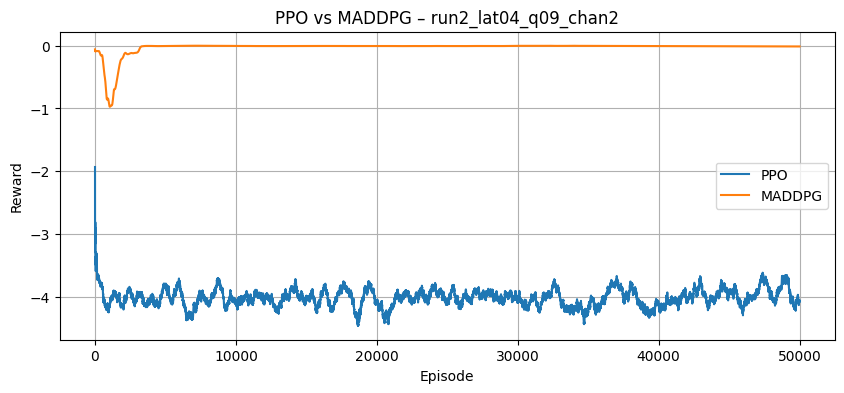

In [85]:
import pandas as pd, matplotlib.pyplot as plt, pathlib

run_id = "run2_lat04_q09_chan2"                 # same ID
d = pathlib.Path("output") / run_id
ppo = pd.read_csv(d / "ppo_rewards.csv")
ddp = pd.read_csv(d / "ddpg_rewards.csv")

plt.figure(figsize=(10,4))
plt.plot(ppo['Episode'], ppo['Reward'].rolling(500,1).mean(), label="PPO")
plt.plot(ddp['Episode'], ddp['Reward'].rolling(500,1).mean(), label="MADDPG")
plt.title(f"PPO vs MADDPG – {run_id}")
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.grid(); plt.legend()
plt.savefig(d / "algo_compare.png"); plt.show()


In [86]:
# metric can be "Reward", "Energy", "Latency", or "Phi"
metric = "Reward"


# THIRD **RUN**

In [95]:
%%writefile run_ppo.py
"""
Run-3 — PPO trainer
───────────────────
• Set run_id and LATENCY / QUALITY / CHANNELS at the top.
• CSV + reward plot saved in output/<run_id>/.
"""
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from env import MECEnv
from ppo_agent import PPOAgent

# ── 1) UNIQUE NAME & DEVICE PARAMS ───────────────────────────────
run_id   = "run3_lat03_q095_chan3"   # ← change per run
LATENCY  = 0.3                       # τ deadline
QUALITY  = 0.95                      # ε QoE
CHANNELS = 3
AGENTS   = 4
EPISODES = 50_000
UPDATE_EVERY = 256

# ── 2) OUTPUT DIR ────────────────────────────────────────────────
outdir = Path("output") / run_id
outdir.mkdir(parents=True, exist_ok=True)
print("Logs →", outdir)

# ── 3) ENV & AGENT ───────────────────────────────────────────────
env = MECEnv(AGENTS)
env.latency_thresholds  = [LATENCY]*AGENTS
env.quality_constraints = [QUALITY]*AGENTS
env.num_channels        = CHANNELS

state_dim  = env.obs_len * AGENTS
action_dim = env.act_len * AGENTS
agent      = PPOAgent(state_dim, action_dim)

# ── 4) TRAIN LOOP ────────────────────────────────────────────────
R,E,L,P               = [],[],[],[]
Sb, Ab, Lpb, Rb       = [],[],[],[]   # independent buffers

for ep in range(1, EPISODES+1):
    s = env.reset(); flat = s.reshape(-1)
    a, lp = agent.select_action(flat)
    ns, r, _, info = env.step(a.reshape(AGENTS, -1))

    Sb.append(flat); Ab.append(a.reshape(-1)); Lpb.append(lp.reshape(-1)); Rb.append(r)
    R.append(r); E.append(info['energy']); L.append(info['latency']); P.append(info['phi'])

    if ep % UPDATE_EVERY == 0:
        returns, G = [], 0
        for rew in reversed(Rb):
            G = rew + agent.g * G
            returns.insert(0, G)
        agent.update(Sb, Ab, Lpb, returns)
        Sb, Ab, Lpb, Rb = [], [], [], []   # reset with new empty lists

    if ep % 1_000 == 0:
        print(f"[PPO-{run_id}] {ep}/{EPISODES}  r={r:.2f}")

# ── 5) SAVE CSV ─────────────────────────────────────────────────
csv_path = outdir / "ppo_rewards.csv"
pd.DataFrame({
    "Episode": range(1, EPISODES+1),
    "Reward" : R,
    "Energy" : E,
    "Latency": L,
    "Phi"    : P
}).to_csv(csv_path, index=False)
print("CSV saved →", csv_path)

# ── 6) SAVE PLOT ────────────────────────────────────────────────
plt.figure(figsize=(8,4))
plt.plot(range(1, EPISODES+1), pd.Series(R).rolling(500,1).mean(), label="Reward MA500")
plt.title(f"PPO – {run_id}"); plt.xlabel("Episode"); plt.ylabel("Reward")
plt.grid(); plt.legend(); plt.savefig(outdir / "reward_curve.png"); plt.show()
print("Plot saved →", outdir / "reward_curve.png")


Overwriting run_ppo.py


In [90]:
%%bash
cat > run_maddpg.py <<'PY'
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from env import MECEnv
from MADDPG import MADDPG

# ---------- must match the PPO run ----------
run_id   = "run3_lat03_q095_chan3"
LATENCY  = 0.3
QUALITY  = 0.95
CHANNELS = 3
AGENTS   = 4
EPISODES = 50_000

outdir = Path("output")/run_id ; outdir.mkdir(parents=True, exist_ok=True)

env = MECEnv(AGENTS)
env.latency_thresholds=[LATENCY]*AGENTS
env.quality_constraints=[QUALITY]*AGENTS
env.num_channels=CHANNELS

agent = MADDPG(AGENTS, env.obs_len, env.act_len)

R,E,L,P = [],[],[],[]
for ep in range(1, EPISODES+1):
    s=env.reset(); a=agent.select_action(s)
    ns,r,_,info = env.step(a)
    agent.store((s,a,[r]*AGENTS,ns)); agent.train()
    R.append(r); E.append(info['energy']); L.append(info['latency']); P.append(info['phi'])
    if ep%1000==0: print(f"[MADDPG-{run_id}] {ep}/{EPISODES} r={r:.2f}")

pd.DataFrame({"Episode":range(1,EPISODES+1),"Reward":R,"Energy":E,"Latency":L,"Phi":P}
            ).to_csv(outdir/"ddpg_rewards.csv",index=False)

plt.figure(figsize=(8,4))
plt.plot(range(1,EPISODES+1), pd.Series(R).rolling(500,1).mean(), label="Reward MA500")
plt.title(f"MADDPG – {run_id}"); plt.xlabel("Episode"); plt.ylabel("Reward")
plt.grid(); plt.legend(); plt.savefig(outdir/"ddpg_curve.png"); plt.close()
PY




In [96]:
!python run_ppo.py

Logs → output/run3_lat03_q095_chan3
[PPO-run3_lat03_q095_chan3] 1000/50000  r=-4.09
[PPO-run3_lat03_q095_chan3] 2000/50000  r=-5.34
[PPO-run3_lat03_q095_chan3] 3000/50000  r=-1.97
[PPO-run3_lat03_q095_chan3] 4000/50000  r=-12.41
[PPO-run3_lat03_q095_chan3] 5000/50000  r=-3.20
[PPO-run3_lat03_q095_chan3] 6000/50000  r=-1.36
[PPO-run3_lat03_q095_chan3] 7000/50000  r=-4.78
[PPO-run3_lat03_q095_chan3] 8000/50000  r=-5.18
[PPO-run3_lat03_q095_chan3] 9000/50000  r=-1.81
[PPO-run3_lat03_q095_chan3] 10000/50000  r=-15.17
[PPO-run3_lat03_q095_chan3] 11000/50000  r=-4.67
[PPO-run3_lat03_q095_chan3] 12000/50000  r=-1.01
[PPO-run3_lat03_q095_chan3] 13000/50000  r=-3.83
[PPO-run3_lat03_q095_chan3] 14000/50000  r=-2.88
[PPO-run3_lat03_q095_chan3] 15000/50000  r=-2.93
[PPO-run3_lat03_q095_chan3] 16000/50000  r=-6.07
[PPO-run3_lat03_q095_chan3] 17000/50000  r=-3.13
[PPO-run3_lat03_q095_chan3] 18000/50000  r=-3.72
[PPO-run3_lat03_q095_chan3] 19000/50000  r=-4.33
[PPO-run3_lat03_q095_chan3] 20000/50000 

In [93]:
!python run_maddpg.py

[MADDPG-run3_lat03_q095_chan3] 1000/50000 r=-0.67
[MADDPG-run3_lat03_q095_chan3] 2000/50000 r=-0.10
[MADDPG-run3_lat03_q095_chan3] 3000/50000 r=-0.02
[MADDPG-run3_lat03_q095_chan3] 4000/50000 r=-0.01
[MADDPG-run3_lat03_q095_chan3] 5000/50000 r=-0.01
[MADDPG-run3_lat03_q095_chan3] 6000/50000 r=-0.00
[MADDPG-run3_lat03_q095_chan3] 7000/50000 r=-0.00
[MADDPG-run3_lat03_q095_chan3] 8000/50000 r=-0.00
[MADDPG-run3_lat03_q095_chan3] 9000/50000 r=-0.00
[MADDPG-run3_lat03_q095_chan3] 10000/50000 r=-0.01
[MADDPG-run3_lat03_q095_chan3] 11000/50000 r=-0.02
[MADDPG-run3_lat03_q095_chan3] 12000/50000 r=-0.01
[MADDPG-run3_lat03_q095_chan3] 13000/50000 r=-0.01
[MADDPG-run3_lat03_q095_chan3] 14000/50000 r=-0.01
[MADDPG-run3_lat03_q095_chan3] 15000/50000 r=-0.01
[MADDPG-run3_lat03_q095_chan3] 16000/50000 r=-0.01
[MADDPG-run3_lat03_q095_chan3] 17000/50000 r=-0.02
[MADDPG-run3_lat03_q095_chan3] 18000/50000 r=-0.01
[MADDPG-run3_lat03_q095_chan3] 19000/50000 r=-0.01
[MADDPG-run3_lat03_q095_chan3] 20000/500

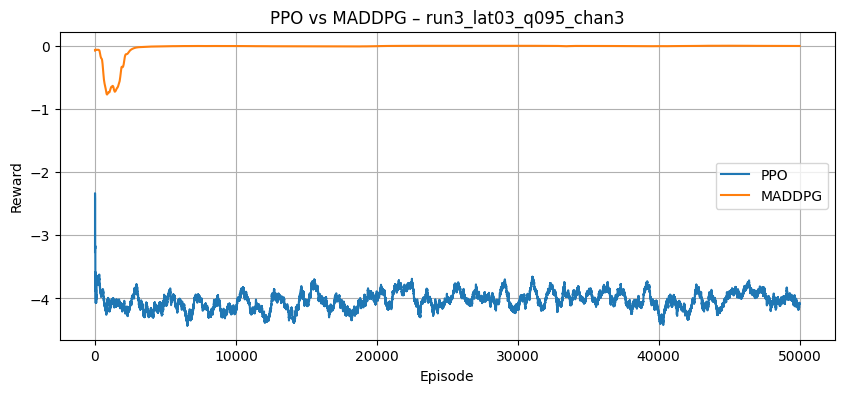

In [97]:
import pandas as pd, matplotlib.pyplot as plt, pathlib
run_id = "run3_lat03_q095_chan3"
d = pathlib.Path("output")/run_id
ppo = pd.read_csv(d/"ppo_rewards.csv")
ddp = pd.read_csv(d/"ddpg_rewards.csv")
plt.figure(figsize=(10,4))
plt.plot(ppo['Episode'], ppo['Reward'].rolling(500,1).mean(), label="PPO")
plt.plot(ddp['Episode'], ddp['Reward'].rolling(500,1).mean(), label="MADDPG")
plt.title(f"PPO vs MADDPG – {run_id}"); plt.xlabel("Episode"); plt.ylabel("Reward")
plt.grid(); plt.legend(); plt.savefig(d/"algo_compare.png"); plt.show()


# FOURTH **RUN**

In [98]:
%%writefile run_ppo.py
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from env import MECEnv
from ppo_agent import PPOAgent

# ── Run-4 parameters ───────────────────────────────────────────
run_id   = "run4_lat02_q10_chan1"
LATENCY  = 0.2      # very strict deadline
QUALITY  = 1.0      # perfect QoE target
CHANNELS = 1        # only one channel
AGENTS   = 4
EPISODES = 50_000
UPDATE_EVERY = 256
# ───────────────────────────────────────────────────────────────

outdir = Path("output")/run_id ; outdir.mkdir(parents=True, exist_ok=True)

env = MECEnv(AGENTS)
env.latency_thresholds  = [LATENCY]*AGENTS
env.quality_constraints = [QUALITY]*AGENTS
env.num_channels        = CHANNELS

sd, ad = env.obs_len*AGENTS, env.act_len*AGENTS
agent  = PPOAgent(sd, ad)

R,E,L,P = [],[],[],[];  Sb,Ab,Lpb,Rb = [],[],[],[]

for ep in range(1, EPISODES+1):
    s = env.reset(); flat=s.reshape(-1)
    a,lp = agent.select_action(flat)
    ns,r,_,info = env.step(a.reshape(AGENTS,-1))

    Sb.append(flat); Ab.append(a.reshape(-1)); Lpb.append(lp.reshape(-1)); Rb.append(r)
    R.append(r); E.append(info['energy']); L.append(info['latency']); P.append(info['phi'])

    if ep%UPDATE_EVERY==0:
        ret,G=[],0
        for rew in reversed(Rb): G=rew+agent.g*G; ret.insert(0,G)
        agent.update(Sb,Ab,Lpb,ret)
        Sb,Ab,Lpb,Rb = [],[],[],[]

    if ep%1000==0: print(f"[PPO-{run_id}] {ep}/{EPISODES} r={r:.2f}")

pd.DataFrame({"Episode":range(1,EPISODES+1),"Reward":R,"Energy":E,"Latency":L,"Phi":P}
            ).to_csv(outdir/"ppo_rewards.csv",index=False)

plt.figure(figsize=(8,4))
plt.plot(range(1,EPISODES+1), pd.Series(R).rolling(500,1).mean(), label="Reward MA500")
plt.title(f"PPO – {run_id}"); plt.xlabel("Episode"); plt.ylabel("Reward"); plt.grid(); plt.legend()
plt.savefig(outdir/"reward_curve.png"); plt.show()


Overwriting run_ppo.py


In [99]:
%%writefile run_maddpg.py
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from env import MECEnv
from MADDPG import MADDPG

# ── same Run-4 parameters ──────────────────────────────────────
run_id   = "run4_lat02_q10_chan1"
LATENCY  = 0.2
QUALITY  = 1.0
CHANNELS = 1
AGENTS   = 4
EPISODES = 50_000
# ───────────────────────────────────────────────────────────────

outdir = Path("output")/run_id ; outdir.mkdir(parents=True, exist_ok=True)

env = MECEnv(AGENTS)
env.latency_thresholds=[LATENCY]*AGENTS
env.quality_constraints=[QUALITY]*AGENTS
env.num_channels=CHANNELS

agent = MADDPG(AGENTS, env.obs_len, env.act_len)

R,E,L,P = [],[],[],[]
for ep in range(1, EPISODES+1):
    s=env.reset(); a=agent.select_action(s)
    ns,r,_,info = env.step(a)
    agent.store((s,a,[r]*AGENTS,ns)); agent.train()
    R.append(r); E.append(info['energy']); L.append(info['latency']); P.append(info['phi'])
    if ep%1000==0: print(f"[MADDPG-{run_id}] {ep}/{EPISODES} r={r:.2f}")

pd.DataFrame({"Episode":range(1,EPISODES+1),"Reward":R,"Energy":E,"Latency":L,"Phi":P}
            ).to_csv(outdir/"ddpg_rewards.csv",index=False)

plt.figure(figsize=(8,4))
plt.plot(range(1,EPISODES+1), pd.Series(R).rolling(500,1).mean(), label="Reward MA500")
plt.title(f"MADDPG – {run_id}"); plt.xlabel("Episode"); plt.ylabel("Reward"); plt.grid(); plt.legend()
plt.savefig(outdir/"ddpg_curve.png"); plt.show()


Overwriting run_maddpg.py


In [100]:
!python run_maddpg.py

[MADDPG-run4_lat02_q10_chan1] 1000/50000 r=-0.44
[MADDPG-run4_lat02_q10_chan1] 2000/50000 r=-0.07
[MADDPG-run4_lat02_q10_chan1] 3000/50000 r=-0.08
[MADDPG-run4_lat02_q10_chan1] 4000/50000 r=-0.03
[MADDPG-run4_lat02_q10_chan1] 5000/50000 r=-0.03
[MADDPG-run4_lat02_q10_chan1] 6000/50000 r=-0.01
[MADDPG-run4_lat02_q10_chan1] 7000/50000 r=-0.01
[MADDPG-run4_lat02_q10_chan1] 8000/50000 r=-0.00
[MADDPG-run4_lat02_q10_chan1] 9000/50000 r=-0.00
[MADDPG-run4_lat02_q10_chan1] 10000/50000 r=-0.00
[MADDPG-run4_lat02_q10_chan1] 11000/50000 r=-0.00
[MADDPG-run4_lat02_q10_chan1] 12000/50000 r=-0.01
[MADDPG-run4_lat02_q10_chan1] 13000/50000 r=-0.01
[MADDPG-run4_lat02_q10_chan1] 14000/50000 r=-0.01
[MADDPG-run4_lat02_q10_chan1] 15000/50000 r=-0.01
[MADDPG-run4_lat02_q10_chan1] 16000/50000 r=-0.00
[MADDPG-run4_lat02_q10_chan1] 17000/50000 r=-0.01
[MADDPG-run4_lat02_q10_chan1] 18000/50000 r=-0.01
[MADDPG-run4_lat02_q10_chan1] 19000/50000 r=-0.00
[MADDPG-run4_lat02_q10_chan1] 20000/50000 r=-0.01
[MADDPG-r

In [101]:
!python run_ppo.py

[PPO-run4_lat02_q10_chan1] 1000/50000 r=-1.11
[PPO-run4_lat02_q10_chan1] 2000/50000 r=-1.51
[PPO-run4_lat02_q10_chan1] 3000/50000 r=-4.27
[PPO-run4_lat02_q10_chan1] 4000/50000 r=-3.63
[PPO-run4_lat02_q10_chan1] 5000/50000 r=-2.43
[PPO-run4_lat02_q10_chan1] 6000/50000 r=-2.83
[PPO-run4_lat02_q10_chan1] 7000/50000 r=-1.72
[PPO-run4_lat02_q10_chan1] 8000/50000 r=-10.84
[PPO-run4_lat02_q10_chan1] 9000/50000 r=-7.03
[PPO-run4_lat02_q10_chan1] 10000/50000 r=-2.34
[PPO-run4_lat02_q10_chan1] 11000/50000 r=-3.73
[PPO-run4_lat02_q10_chan1] 12000/50000 r=-6.73
[PPO-run4_lat02_q10_chan1] 13000/50000 r=-8.20
[PPO-run4_lat02_q10_chan1] 14000/50000 r=-6.49
[PPO-run4_lat02_q10_chan1] 15000/50000 r=-5.20
[PPO-run4_lat02_q10_chan1] 16000/50000 r=-3.37
[PPO-run4_lat02_q10_chan1] 17000/50000 r=-2.68
[PPO-run4_lat02_q10_chan1] 18000/50000 r=-4.02
[PPO-run4_lat02_q10_chan1] 19000/50000 r=-0.21
[PPO-run4_lat02_q10_chan1] 20000/50000 r=-2.17
[PPO-run4_lat02_q10_chan1] 21000/50000 r=-4.85
[PPO-run4_lat02_q10_c

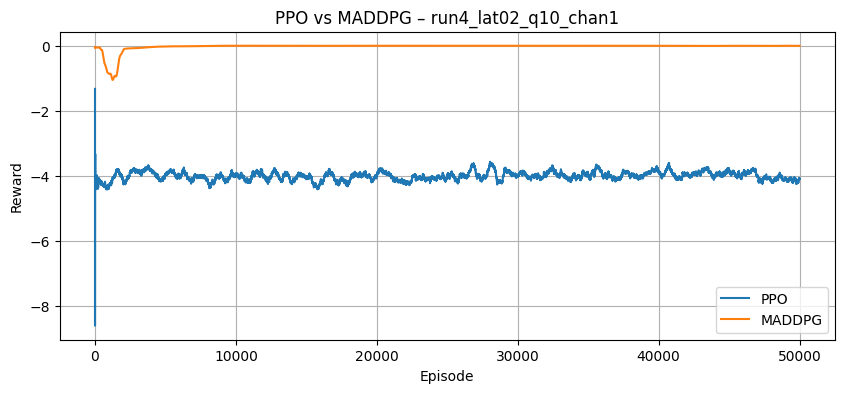

In [102]:
import pandas as pd, matplotlib.pyplot as plt, pathlib
d = pathlib.Path("output")/"run4_lat02_q10_chan1"
ppo = pd.read_csv(d/"ppo_rewards.csv")
ddp = pd.read_csv(d/"ddpg_rewards.csv")
plt.figure(figsize=(10,4))
plt.plot(ppo['Episode'], ppo['Reward'].rolling(500,1).mean(), label="PPO")
plt.plot(ddp['Episode'], ddp['Reward'].rolling(500,1).mean(), label="MADDPG")
plt.title("PPO vs MADDPG – run4_lat02_q10_chan1"); plt.xlabel("Episode"); plt.ylabel("Reward")
plt.grid(); plt.legend(); plt.savefig(d/"algo_compare.png"); plt.show()


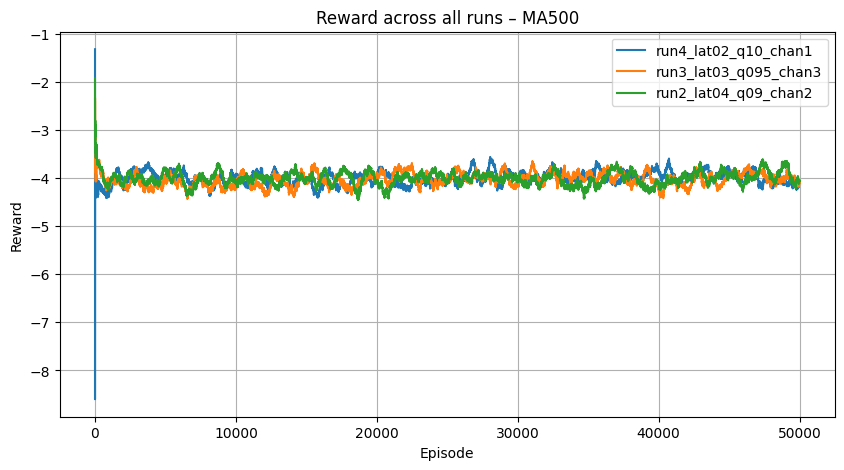

In [103]:
import pandas as pd, matplotlib.pyplot as plt, pathlib, os
root = pathlib.Path("output")
metric = "Reward"; smooth=500
plt.figure(figsize=(10,5))
for run_dir in root.iterdir():
    csv = run_dir/"ppo_rewards.csv"
    if not csv.exists(): continue
    d = pd.read_csv(csv)
    plt.plot(d['Episode'], d[metric].rolling(smooth,1).mean(), label=run_dir.name)
plt.title(f"{metric} across all runs – MA{smooth}"); plt.xlabel("Episode"); plt.ylabel(metric)
plt.grid(); plt.legend(); plt.savefig(root/f"compare_{metric.lower()}_50k.png"); plt.show()


# FIFTH **RUN**

In [109]:
%%writefile run_ppo.py
# Run-5 PPO trainer (lat 0.25, q 0.92, 2 channels)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from env import MECEnv
from ppo_agent import PPOAgent

# ── configuration ───────────────────────────
run_id   = "run5_lat025_q092_chan2"
LATENCY  = 0.25
QUALITY  = 0.92
CHANNELS = 2
AGENTS   = 4
EPISODES = 50_000
UPDATE_EVERY = 256
# ────────────────────────────────────────────

outdir = Path("output") / run_id
outdir.mkdir(parents=True, exist_ok=True)

env = MECEnv(AGENTS)
env.latency_thresholds  = [LATENCY]*AGENTS
env.quality_constraints = [QUALITY]*AGENTS
env.num_channels        = CHANNELS

state_dim  = env.obs_len * AGENTS
action_dim = env.act_len * AGENTS
agent      = PPOAgent(state_dim, action_dim)

# logs
R,E,L,P = [],[],[],[]
Sb,Ab,Lpb,Rb = [],[],[],[]

for ep in range(1, EPISODES+1):
    s = env.reset(); flat=s.reshape(-1)
    a,lp = agent.select_action(flat)
    ns,r,_,info = env.step(a.reshape(AGENTS,-1))

    Sb.append(flat); Ab.append(a.reshape(-1)); Lpb.append(lp.reshape(-1)); Rb.append(r)
    R.append(r); E.append(info['energy']); L.append(info['latency']); P.append(info['phi'])

    if ep % UPDATE_EVERY == 0:
        G = 0; returns = []
        for rew in reversed(Rb):
            G = rew + agent.g * G
            returns.insert(0, G)
        agent.update(Sb, Ab, Lpb, returns)
        Sb,Ab,Lpb,Rb = [],[],[],[]

    if ep % 1_000 == 0:
        print(f"[PPO-{run_id}] {ep}/{EPISODES}  r={r:.2f}")

# save CSV
pd.DataFrame({
    "Episode": range(1, EPISODES+1),
    "Reward" : R,
    "Energy" : E,
    "Latency": L,
    "Phi"    : P
}).to_csv(outdir / "ppo_rewards.csv", index=False)

# plot
plt.figure(figsize=(8,4))
plt.plot(range(1,EPISODES+1), pd.Series(R).rolling(500,1).mean(), label="Reward MA500")
plt.title(f"PPO – {run_id}")
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.grid(); plt.legend()
plt.savefig(outdir / "reward_curve.png"); plt.show()


Overwriting run_ppo.py


In [108]:
%%writefile run_maddpg.py
# Run-5 MADDPG trainer (lat 0.25, q 0.92, 2 channels)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from env import MECEnv
from MADDPG import MADDPG

# ── same configuration as PPO ───────────────
run_id   = "run5_lat025_q092_chan2"
LATENCY  = 0.25
QUALITY  = 0.92
CHANNELS = 2
AGENTS   = 4
EPISODES = 50_000
# ────────────────────────────────────────────

outdir = Path("output") / run_id
outdir.mkdir(parents=True, exist_ok=True)

env = MECEnv(AGENTS)
env.latency_thresholds  = [LATENCY]*AGENTS
env.quality_constraints = [QUALITY]*AGENTS
env.num_channels        = CHANNELS

agent = MADDPG(AGENTS, env.obs_len, env.act_len)

R,E,L,P = [],[],[],[]
for ep in range(1, EPISODES+1):
    s = env.reset()
    a = agent.select_action(s)
    ns,r,_,info = env.step(a)

    agent.store((s,a,[r]*AGENTS,ns))
    agent.train()

    R.append(r); E.append(info['energy']); L.append(info['latency']); P.append(info['phi'])
    if ep % 1_000 == 0:
        print(f"[MADDPG-{run_id}] {ep}/{EPISODES} r={r:.2f}")

# save CSV
pd.DataFrame({
    "Episode": range(1, EPISODES+1),
    "Reward" : R,
    "Energy" : E,
    "Latency": L,
    "Phi"    : P
}).to_csv(outdir / "ddpg_rewards.csv", index=False)

# plot
plt.figure(figsize=(8,4))
plt.plot(range(1,EPISODES+1), pd.Series(R).rolling(500,1).mean(), label="Reward MA500")
plt.title(f"MADDPG – {run_id}")
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.grid(); plt.legend()
plt.savefig(outdir / "ddpg_curve.png"); plt.show()


Overwriting run_maddpg.py


In [110]:
!python run_ppo.py


[PPO-run5_lat025_q092_chan2] 1000/50000  r=-10.24
[PPO-run5_lat025_q092_chan2] 2000/50000  r=-13.09
[PPO-run5_lat025_q092_chan2] 3000/50000  r=-3.09
[PPO-run5_lat025_q092_chan2] 4000/50000  r=-0.39
[PPO-run5_lat025_q092_chan2] 5000/50000  r=-3.24
[PPO-run5_lat025_q092_chan2] 6000/50000  r=-6.45
[PPO-run5_lat025_q092_chan2] 7000/50000  r=-4.16
[PPO-run5_lat025_q092_chan2] 8000/50000  r=-0.92
[PPO-run5_lat025_q092_chan2] 9000/50000  r=-3.89
[PPO-run5_lat025_q092_chan2] 10000/50000  r=-10.92
[PPO-run5_lat025_q092_chan2] 11000/50000  r=-0.78
[PPO-run5_lat025_q092_chan2] 12000/50000  r=-5.12
[PPO-run5_lat025_q092_chan2] 13000/50000  r=-1.11
[PPO-run5_lat025_q092_chan2] 14000/50000  r=-4.17
[PPO-run5_lat025_q092_chan2] 15000/50000  r=-6.34
[PPO-run5_lat025_q092_chan2] 16000/50000  r=-3.04
[PPO-run5_lat025_q092_chan2] 17000/50000  r=-3.95
[PPO-run5_lat025_q092_chan2] 18000/50000  r=-4.32
[PPO-run5_lat025_q092_chan2] 19000/50000  r=-1.60
[PPO-run5_lat025_q092_chan2] 20000/50000  r=-3.19
[PPO-r

In [111]:
!python run_maddpg.py


[MADDPG-run5_lat025_q092_chan2] 1000/50000 r=-0.20
[MADDPG-run5_lat025_q092_chan2] 2000/50000 r=-0.07
[MADDPG-run5_lat025_q092_chan2] 3000/50000 r=-0.10
[MADDPG-run5_lat025_q092_chan2] 4000/50000 r=-0.05
[MADDPG-run5_lat025_q092_chan2] 5000/50000 r=-0.05
[MADDPG-run5_lat025_q092_chan2] 6000/50000 r=-0.02
[MADDPG-run5_lat025_q092_chan2] 7000/50000 r=-0.06
[MADDPG-run5_lat025_q092_chan2] 8000/50000 r=-0.05
[MADDPG-run5_lat025_q092_chan2] 9000/50000 r=-0.06
[MADDPG-run5_lat025_q092_chan2] 10000/50000 r=-0.02
[MADDPG-run5_lat025_q092_chan2] 11000/50000 r=-0.09
[MADDPG-run5_lat025_q092_chan2] 12000/50000 r=-0.05
[MADDPG-run5_lat025_q092_chan2] 13000/50000 r=-0.07
[MADDPG-run5_lat025_q092_chan2] 14000/50000 r=-0.05
[MADDPG-run5_lat025_q092_chan2] 15000/50000 r=-0.04
[MADDPG-run5_lat025_q092_chan2] 16000/50000 r=-0.05
[MADDPG-run5_lat025_q092_chan2] 17000/50000 r=-0.05
[MADDPG-run5_lat025_q092_chan2] 18000/50000 r=-0.05
[MADDPG-run5_lat025_q092_chan2] 19000/50000 r=-0.04
[MADDPG-run5_lat025_q

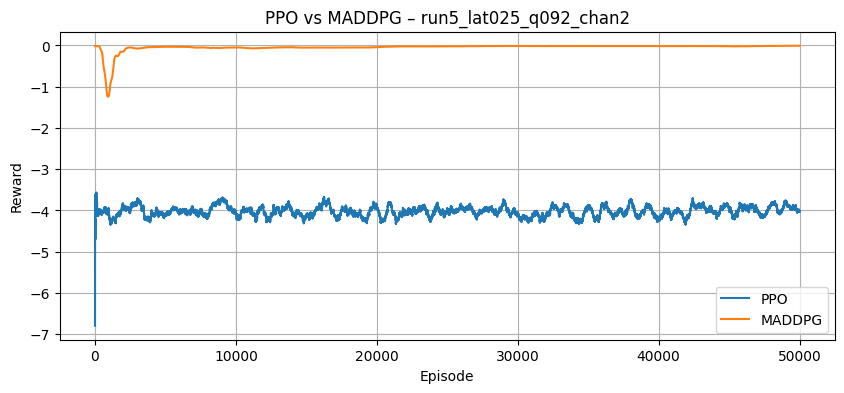

In [113]:
import pandas as pd, matplotlib.pyplot as plt, pathlib
run_id = "run5_lat025_q092_chan2"          # change per run
d = pathlib.Path("output") / run_id
ppo = pd.read_csv(d / "ppo_rewards.csv")
ddp = pd.read_csv(d / "ddpg_rewards.csv")

plt.figure(figsize=(10,4))
plt.plot(ppo["Episode"], ppo["Reward"].rolling(500,1).mean(), label="PPO")
plt.plot(ddp["Episode"], ddp["Reward"].rolling(500,1).mean(), label="MADDPG")
plt.title(f"PPO vs MADDPG – {run_id}")
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.grid(); plt.legend()
plt.savefig(d / "algo_compare.png"); plt.show()


In [117]:
import shutil, pathlib, glob

root   = pathlib.Path("output")
run1   = root / "run1_lat05_q09_chan2"     # ← rename if needed
run1.mkdir(parents=True, exist_ok=True)

# list of single-run files sitting in output/
file_patterns = [
    "ppo_rewards.csv",
    "ddpg_rewards.csv",
    "reward_curve.png",          # if it exists
    "ddpg_curve.png",            # if it exists
    "reward_compare_50k.png"     # your first comparison plot
]

for pattern in file_patterns:
    for f in root.glob(pattern):
        print("moving →", f.name)
        shutil.move(str(f), run1 / f.name)

print("✅ First-run files now in:", run1)
print("remaining files in output/:", [p.name for p in root.iterdir()])


moving → ppo_rewards.csv
moving → ddpg_rewards.csv
moving → reward_compare_50k.png
✅ First-run files now in: output/run1_lat05_q09_chan2
remaining files in output/: ['.ipynb_checkpoints', 'run1_lat05_q09', 'run4_lat02_q10_chan1', 'run5_lat025_q092_chan2', 'run1_lat05_q09_chan2', 'compare_phi_50k.png', 'run3_lat03_q095_chan3', 'compare_latency_50k.png', 'compare_reward_50k.png', 'run2_lat04_q09_chan2']


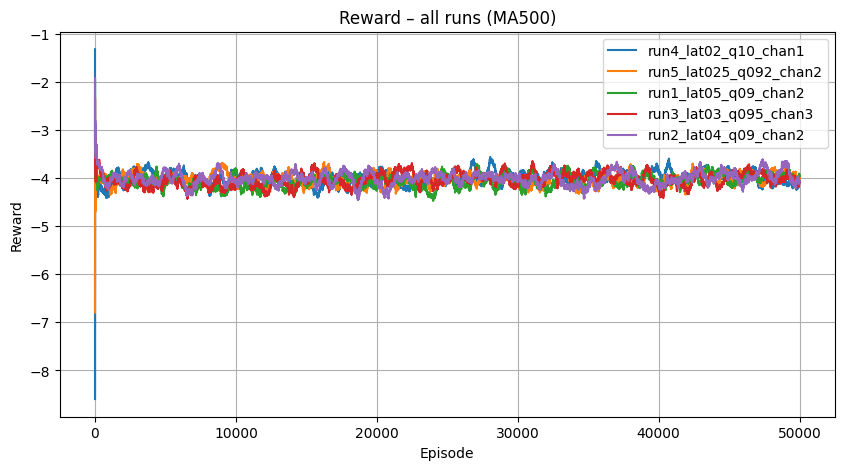

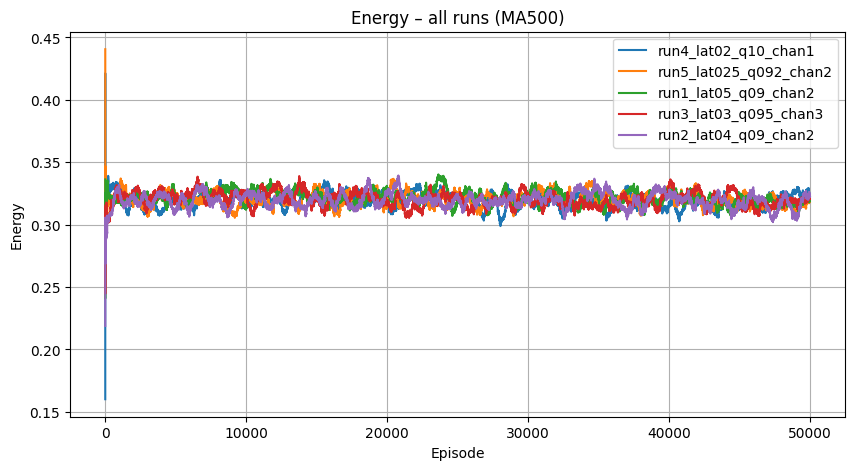

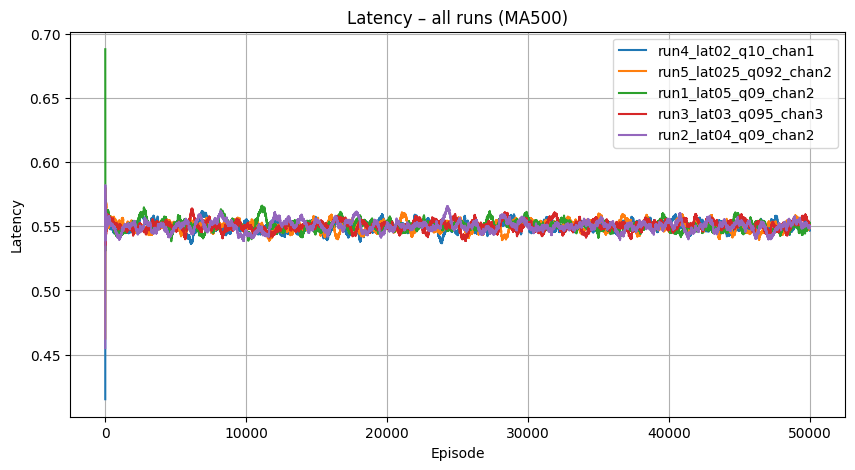

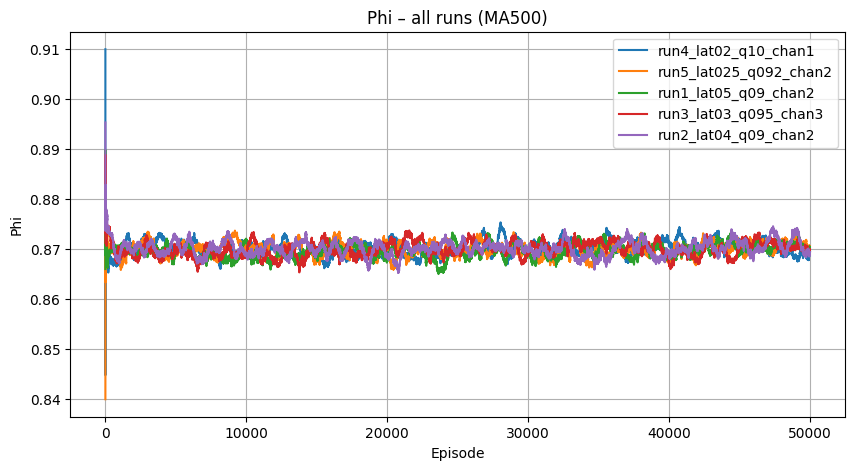

In [119]:
import pandas as pd, matplotlib.pyplot as plt, pathlib
root = pathlib.Path("output")
smooth = 500                            # moving-average window

for metric in ("Reward", "Energy", "Latency", "Phi"):
    plt.figure(figsize=(10,5))
    for run_dir in root.iterdir():
        csv = run_dir / "ppo_rewards.csv"
        if not csv.exists(): continue
        df = pd.read_csv(csv)
        plt.plot(df["Episode"],
                 df[metric].rolling(smooth, 1).mean(),
                 label=run_dir.name)
    plt.title(f"{metric} – all runs (MA{smooth})")
    plt.xlabel("Episode"); plt.ylabel(metric); plt.grid(); plt.legend()
    plt.savefig(root / f"compare_{metric.lower()}_50k.png")
    plt.show()


In [122]:
# 1️⃣  Mount Google Drive (only once per session)
from google.colab import drive
drive.mount('/content/drive')     # follow the auth link if prompted

# 2️⃣  Zip the entire project folder (code + output)
import time, pathlib, shutil

timestamp = time.strftime("%Y%m%d_%H%M")
proj_dir  = pathlib.Path("/content/workspace_50k_test")          # everything here
zip_base  = f"/content/drive/MyDrive/DRL_50k_full_project_{timestamp}"  # without .zip

shutil.make_archive(zip_base, 'zip', root_dir=proj_dir)

print("✅ Full project archived →", zip_base + ".zip")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Full project archived → /content/drive/MyDrive/DRL_50k_full_project_20250522_2027.zip
